In [2]:
import zipfile

# Replace 'your_file.zip' with the name of your zip file.
# Try using cp1252 if the file is from a Windows environment.
zip_filename = 'cracked.zip'
extraction_directory = 'extracted_files'
encoding_used = 'cp437'  # Change this to 'cp437', 'latin-1', etc., as needed.

# Open the zip file with the specified encoding.
with zipfile.ZipFile(zip_filename, 'r', encoding=encoding_used) as z:
    # Print the list of file names to check if they look correct.
    file_names = z.namelist()
    print("Files in the zip:", file_names)
    
    # Extract all files to the specified directory.
    z.extractall(extraction_directory)

print(f"Extraction complete. Files are available in '{extraction_directory}'.")


TypeError: ZipFile.__init__() got an unexpected keyword argument 'encoding'

In [3]:
!unzip cracked.zip -d extracted_files

Archive:  cracked.zip
  inflating: extracted_files/Decks/Cracked/7001-115.jpg  
  inflating: extracted_files/Decks/Cracked/7001-139.jpg  
  inflating: extracted_files/Decks/Cracked/7001-151.jpg  
  inflating: extracted_files/Decks/Cracked/7001-157.jpg  
  inflating: extracted_files/Decks/Cracked/7001-169.jpg  
  inflating: extracted_files/Decks/Cracked/7001-17.jpg  
  inflating: extracted_files/Decks/Cracked/7001-173.jpg  
  inflating: extracted_files/Decks/Cracked/7001-178.jpg  
  inflating: extracted_files/Decks/Cracked/7001-187.jpg  
  inflating: extracted_files/Decks/Cracked/7001-2.jpg  
  inflating: extracted_files/Decks/Cracked/7001-208.jpg  
  inflating: extracted_files/Decks/Cracked/7001-21.jpg  
  inflating: extracted_files/Decks/Cracked/7001-22.jpg  
  inflating: extracted_files/Decks/Cracked/7001-225.jpg  
  inflating: extracted_files/Decks/Cracked/7001-226.jpg  
  inflating: extracted_files/Decks/Cracked/7001-236.jpg  
  inflating: extracted_files/Decks/Cracked/7001-237.jpg

In [9]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory
import os



# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [12]:
!pip install keras 

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 2.3 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 670.4/670.4 kB 3.4 MB/s eta 0:00:00a 0:00:01


In [14]:
!pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.7/252.7 MB 1.5 MB/s eta 0:00:0000:0100:05
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 931.0 kB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 1.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 1.1 MB/s eta 0:00:00a 0:00:01


In [17]:
from keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras import Model,layers
import tensorflow as tf
import keras

import matplotlib.pyplot as plt
from matplotlib.image import imread
import cv2

ImportError: cannot import name 'ImageDataGenerator' from 'keras.preprocessing.image' (/opt/anaconda3/lib/python3.12/site-packages/keras/api/preprocessing/image/__init__.py)

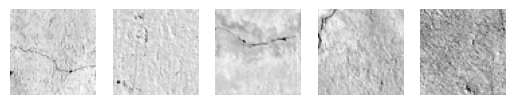

In [20]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# Set the path to your folder
folder_path = 'extracted_files/Decks/Cracked'  # adjust if needed

# Initialize list to store image arrays
images = []

# Loop through files in the folder
for filename in os.listdir(folder_path):
    if filename.endswith('.jpg') or filename.endswith('.png'):
        img_path = os.path.join(folder_path, filename)
        img = Image.open(img_path).convert('L')  # Convert to grayscale
        img = img.resize((64, 64))  # Resize for uniformity
        img_array = np.array(img)
        images.append(img_array)
        # Just load a few for visualization
        if len(images) >= 5:
            break

# Display the first few images
for i, img in enumerate(images):
    plt.subplot(1, 5, i + 1)
    plt.imshow(img, cmap='gray')
    plt.axis('off')
plt.show()

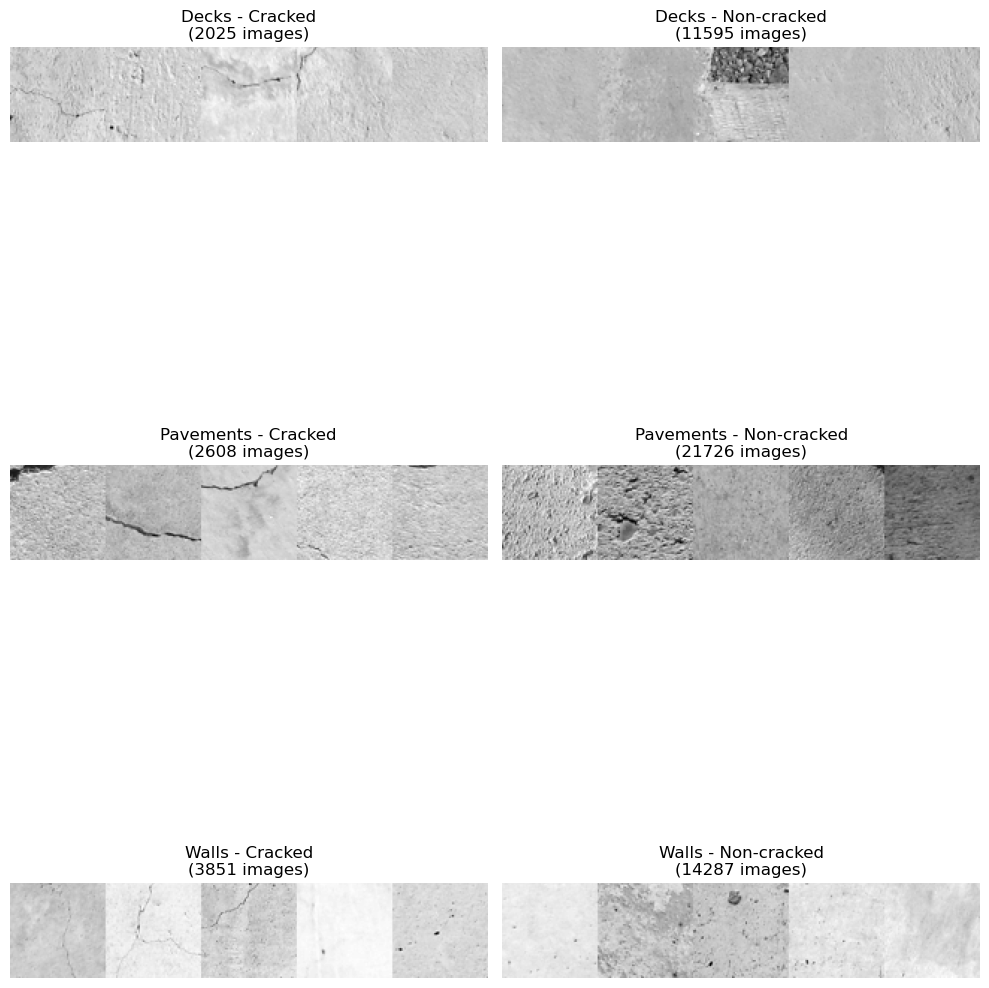

In [22]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# Define the root folder
root_folder = 'extracted_files'

# Define the categories and states (sub-folders within each category)
categories = ['Decks', 'Pavements', 'Walls']
states = ['Cracked', 'Non-cracked']  # Adjust folder names if needed

# Dictionary to store image arrays for each category and state
images = {}

# Loop through each category and state
for category in categories:
    images[category] = {}
    for state in states:
        folder_path = os.path.join(root_folder, category, state)
        images[category][state] = []
        
        # Check that the folder exists
        if not os.path.exists(folder_path):
            print(f"Folder not found: {folder_path}")
            continue
        
        # Loop through image files in the folder
        for filename in os.listdir(folder_path):
            if filename.lower().endswith(('.jpg', '.png')):
                img_path = os.path.join(folder_path, filename)
                try:
                    img = Image.open(img_path).convert('L')  # Convert to grayscale
                    img = img.resize((64, 64))  # Resize for uniformity
                    img_array = np.array(img)
                    images[category][state].append(img_array)
                except Exception as e:
                    print(f"Error processing {img_path}: {e}")

# Display up to 5 images from each category/state for visualization
fig, axes = plt.subplots(len(categories), len(states), figsize=(10, 15))

for i, category in enumerate(categories):
    for j, state in enumerate(states):
        ax = axes[i, j] if len(categories) > 1 else axes[j]
        sample_images = images[category][state]
        if len(sample_images) == 0:
            ax.text(0.5, 0.5, "No Images", horizontalalignment='center', verticalalignment='center')
            ax.set_title(f"{category} - {state}")
            ax.axis('off')
        else:
            # Concatenate up to 5 images horizontally for a montage view
            montage_images = sample_images[:5]
            montage = np.hstack(montage_images)
            ax.imshow(montage, cmap='gray')
            ax.set_title(f"{category} - {state}\n({len(sample_images)} images)")
            ax.axis('off')

plt.tight_layout()
plt.show()


Total images loaded: 56092
Training samples: 44873, Testing samples: 11219


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 62, 62, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 682,753 (2.60 MB)

 Trainable params: 682,753 (2.60 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1403/1403 ━━━━━━━━━━━━━━━━━━━━ 46s 33ms/step - accuracy: 0.9944 - loss: 0.0370 - val_accuracy: 1.0000 - val_loss: 2.4418e-28
Epoch 2/10
1403/1403 ━━━━━━━━━━━━━━━━━━━━ 46s 33ms/step - accuracy: 1.0000 - loss: 2.2443e-23 - val_accuracy: 1.0000 - val_loss: 2.4418e-28
Epoch 3/10
1403/1403 ━━━━━━━━━━━━━━━━━━━━ 46s 33ms/step - accuracy: 1.0000 - loss: 4.7171e-23 - val_accuracy: 1.0000 - val_loss: 2.4418e-28
Epoch 4/10
1403/1403 ━━━━━━━━━━━━━━━━━━━━ 47s 33ms/step - accuracy: 1.0000 - loss: 6.0377e-23 - val_accuracy: 1.0000 - val_loss: 2.4418e-28
Epoch 5/10
1403/1403 ━━━━━━━━━━━━━━━━━━━━ 47s 33ms/step - accuracy: 1.0000 - loss: 7.9455e-23 - val_accuracy: 1.0000 - val_loss: 2.4418e-28
Epoch 6/10
1403/1403 ━━━━━━━━━━━━━━━━━━━━ 46s 33ms/step - accuracy: 1.0000 - loss: 1.7733e-23 - val_accuracy: 1.0000 - val_loss: 2.4418e-28
Epoch 7/10
1403/1403 ━━━━━━━━━━━━━━━━━━━━ 46s 33ms/step - accuracy: 1.0000 - loss: 1.4185e-23 - val_accuracy: 1.0000 - val_loss: 2.4418e-28
Epoch 8/10
1403/1403 ━━━

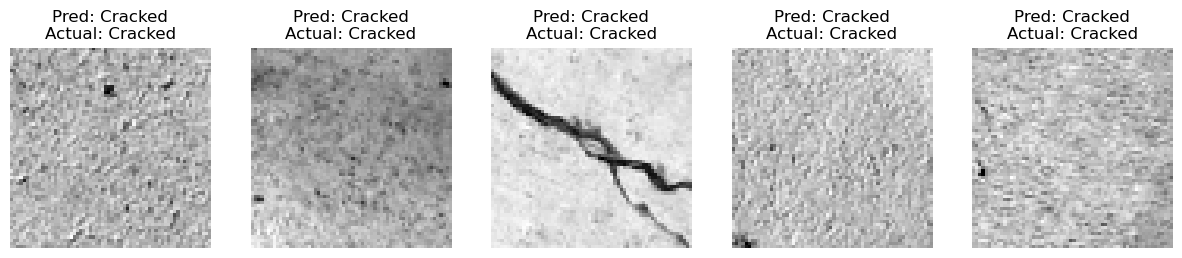

In [25]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import random
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split

# 1. Define paths and parameters
root_folder = 'extracted_files'  # Root folder where images are extracted
categories = ['Decks', 'Pavements', 'Walls']   # Main categories
states = ['Cracked', 'Non-cracked']              # Sub-folders for labels
image_size = (64, 64)  # Target size for resizing images

# Lists to accumulate the image data and labels
all_images = []
all_labels = []

# 2. Loop through each folder and load images with corresponding labels
for category in categories:
    for state in states:
        folder_path = os.path.join(root_folder, category, state)
        if not os.path.exists(folder_path):
            print(f"Folder not found: {folder_path}")
            continue
        
        # Process each image file in the current folder
        for filename in os.listdir(folder_path):
            if filename.lower().endswith(('.jpg', '.png')):
                img_path = os.path.join(folder_path, filename)
                try:
                    # Open, convert to grayscale, and resize the image
                    img = Image.open(img_path).convert('L')
                    img = img.resize(image_size)
                    img_array = np.array(img)
                    all_images.append(img_array)
                    
                    # Labeling: cracked images as 1, non-cracked as 0
                    label = 1 if 'cracked' in state.lower() else 0
                    all_labels.append(label)
                except Exception as e:
                    print(f"Error processing {img_path}: {e}")

# 3. Convert lists to numpy arrays and add a channel dimension
X = np.array(all_images)  # Shape: (num_samples, height, width)
X = np.expand_dims(X, -1) # New shape: (num_samples, height, width, 1)
y = np.array(all_labels)

print(f"Total images loaded: {X.shape[0]}")

# 4. Shuffle the dataset
indices = np.arange(X.shape[0])
np.random.shuffle(indices)
X = X[indices]
y = y[indices]

# 5. Split the data into training and testing sets (e.g., 80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training samples: {X_train.shape[0]}, Testing samples: {X_test.shape[0]}")

# 6. Build a CNN classification model
input_shape = (image_size[0], image_size[1], 1)

model = models.Sequential([
    layers.Input(shape=input_shape),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')  # Sigmoid for binary classification
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Optionally, print the model summary
model.summary()

# 7. Train the model (adjust epochs as needed)
epochs = 10
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=epochs)

# 8. Evaluate the model on the test set
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}")

# 9. Visualize predictions on some random test images
num_samples = 5
sample_indices = random.sample(range(X_test.shape[0]), num_samples)

plt.figure(figsize=(15, 3))
for i, idx in enumerate(sample_indices):
    img = X_test[idx].reshape(image_size)
    prediction = model.predict(np.expand_dims(X_test[idx], axis=0))[0][0]
    pred_label = "Cracked" if prediction > 0.5 else "Non-cracked"
    actual_label = "Cracked" if y_test[idx] == 1 else "Non-cracked"
    
    plt.subplot(1, num_samples, i + 1)
    plt.imshow(img, cmap='gray')
    plt.title(f"Pred: {pred_label}\nActual: {actual_label}")
    plt.axis('off')
plt.show()
